# Backpropagation Exploration





In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.io import arff
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import LabelBinarizer

# 1 Avoiding Overfitting: Early Stopping and Loss Regularization

## Case 1: No overfit avoidance
We train the sklearn [MLP classifier](https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html#sklearn.neural_network.MLPClassifier) on the [Iris Dataset](https://raw.githubusercontent.com/cs472ta/CS472/master/datasets/iris.arff) using 3 output nodes (1 per class). 

We use default parameters except for the following:
- `hidden_layer_sizes = [64]` - One hidden layer with 64 hidden nodes
- `activation = 'logistic'` 
- `solver = 'sgd'`
- `alpha = 0`
- `batch_size = 1` 
- `learning_rate_init = 0.01`
- `shuffle = True`
- `momentum = 0`
- `n_iter_no_change = 50`
- `max_iterations = 10000`

Using a random 80/20 split of the data, run it a few times with different random training/test splits and give average values for
- Number of iterations until convergence
- Training set accuracy
- Test set accuracy

For one run observing the softmax probabilities on the test set using `clf.predict_proba`

In [2]:
!wget https://raw.githubusercontent.com/cs472ta/CS472/master/datasets/iris.arff

--2026-07-22 17:50:27--  https://raw.githubusercontent.com/cs472ta/CS472/master/datasets/iris.arff
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.109.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 7485 (7.3K) [text/plain]
Saving to: ‘iris.arff.10’

iris.arff.10        100%[===================>]   7.31K  --.-KB/s    in 0s      

2026-07-22 17:50:28 (92.1 MB/s) - ‘iris.arff.10’ saved [7485/7485]



In [6]:
def train_and_evaluate_iris(
    alpha=0,
    hidden_layer_sizes=(64,),
    activation="logistic",
    solver="sgd",
    batch_size=1,
    learning_rate_init=0.01,
    shuffle=True,
    momentum=0,
    n_iter_no_change=50,
    max_iter=10000,
    random_state=42,
    test_size=0.2,
    filename="iris.arff",
):
    """Load the Iris data, train an MLPClassifier, and return evaluation metrics."""
    data, _ = arff.loadarff(filename)
    df = pd.DataFrame(data)

    # Decode byte strings to strings
    for col in df.select_dtypes(["object"]):
        df[col] = df[col].str.decode("utf-8")

    X = df.iloc[:, :-1]
    y = df.iloc[:, -1]

    # One-hot encode the target variable
    encoder = LabelBinarizer()
    y_onehot = encoder.fit_transform(y)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y_onehot, test_size=test_size, random_state=random_state
    )

    clf = MLPClassifier(
        hidden_layer_sizes=hidden_layer_sizes,
        activation=activation,
        solver=solver,
        alpha=alpha,
        batch_size=batch_size,
        learning_rate_init=learning_rate_init,
        shuffle=shuffle,
        momentum=momentum,
        n_iter_no_change=n_iter_no_change,
        max_iter=max_iter,
        random_state=random_state,
    )

    clf.fit(X_train, y_train)

    return {
        "classifier": clf,
        "iterations": clf.n_iter_,
        "train_accuracy": clf.score(X_train, y_train),
        "test_accuracy": clf.score(X_test, y_test),
        "probabilities": clf.predict_proba(X_test),
    }

In [8]:
results0 = train_and_evaluate_iris(random_state=43)
print(f"Number of iterations until convergence: {results0['iterations']}")
print(f"Training set accuracy: {results0['train_accuracy']}")
print(f"Test set accuracy: {results0['test_accuracy']}")

Number of iterations until convergence: 343
Training set accuracy: 0.975
Test set accuracy: 0.9333333333333333


### Discussion
- How long did the classifier take?
- What was the accuracy on the training set?
- What was the accuracy on the test set?
- Is there evidence of overfitting? What could reduce the effects of overfitting?

In the shown run, the MLP classifier converged after 343 iterations, with training accuracy `0.975` and test accuracy `0.9333`. Across the recorded runs, the training and test accuracies were both high and generally close, so there was not strong evidence of overfitting. Because Iris is a small, simple dataset, it may not expose overfitting as clearly as a noisier dataset.

## 1.2 Early Stopping (Validation Set)

- Do the same as above but this time with early stopping
- Use a validation set taken from the training set for your stopping criteria. Using 10-15% of the training set for a validation set is common. You do this simply by setting the MLPClassifier early_stopping, validation_fraction, and n_iter_no_change parameters.
- Run it a few times with different training/test splits and give average values for
    - Number of iterations until convergence
    - Training set accuracy
    - Test set accuracy
    - Best validation score (MLPClassifer attribute best_validation_score_)
- For one run create a graph with validation set accuracy (*y*-axis) vs epochs (*x*-axis). Hint: MLPClassifer attribute validation_scores_

Note: Due to the simplicity of and lack of noise in the iris data set we will not see the accuracy improvements that early stopping or loss regularization can give for more complex noisy datasets.  In particular, early stopping will have lower than expected results because with a very small VS taken from a very small training set there is less data to train on and more variance with the VS score.  Thus, we will probably get lower accuracies for VS than normal training for this less typical case.  But at least we will get practice on using early stopping and loss regularization for future data sets.

Average Number of iterations until convergence: 110.9
Average Training set accuracy: 0.8949999999999999
Average Test set accuracy: 0.8366666666666667
Average Best validation score: 0.9666666666666666


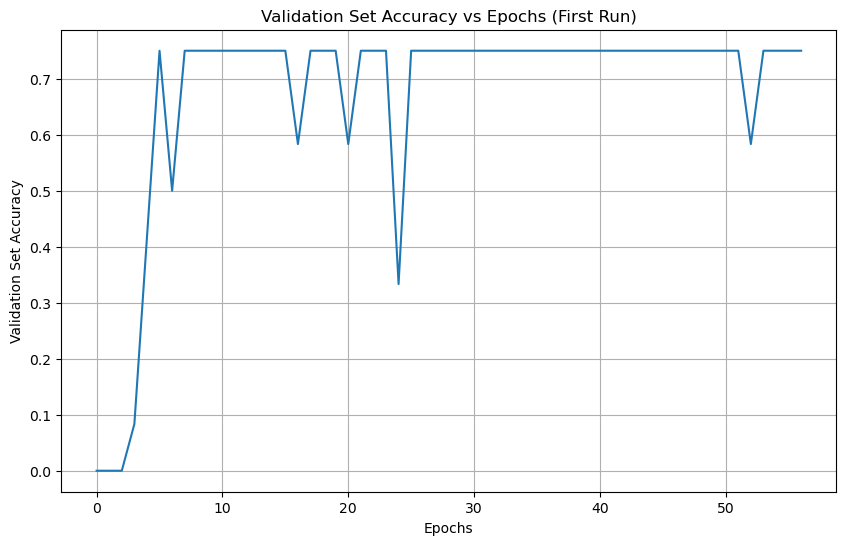

In [4]:
# Load the dataset
filename = "iris.arff"
data, meta = arff.loadarff(filename)
df = pd.DataFrame(data)

# Decode byte strings to strings
for col in df.select_dtypes(["object"]):
    df[col] = df[col].str.decode("utf-8")

X = df.iloc[:, :-1]
y = df.iloc[:, -1]

# one-hot encode the target variable
encoder = LabelBinarizer()
y_onehot = encoder.fit_transform(y)

# Prepare to collect results for multiple runs
num_runs = 10  # Number of runs to average results
iterations_list = []
train_accuracy_list = []
test_accuracy_list = []
best_validation_score_list = []
validation_scores_list = []

for run in range(num_runs):
    # train test split with different random states for each run
    X_train, X_test, y_train, y_test = train_test_split(
        X, y_onehot, test_size=0.2, random_state=run
    )

    # Initialize and train the MLPClassifier with early stopping
    clf = MLPClassifier(
        hidden_layer_sizes=[64],
        activation="logistic",
        solver="sgd",
        alpha=0,
        batch_size=1,
        learning_rate_init=0.01,
        shuffle=True,
        momentum=0,
        n_iter_no_change=50,
        max_iter=10000,
        early_stopping=True,
        validation_fraction=0.1,
        random_state=run,
    )

    clf.fit(X_train, y_train)

    # results
    iterations_list.append(clf.n_iter_)
    train_accuracy_list.append(clf.score(X_train, y_train))
    test_accuracy_list.append(clf.score(X_test, y_test))
    best_validation_score_list.append(clf.best_validation_score_)
    validation_scores_list.append(clf.validation_scores_)


# average results
avg_iterations = np.mean(iterations_list)
avg_train_accuracy = np.mean(train_accuracy_list)
avg_test_accuracy = np.mean(test_accuracy_list)
avg_best_validation_score = np.mean(best_validation_score_list)

print(f"Average Number of iterations until convergence: {avg_iterations}")
print(f"Average Training set accuracy: {avg_train_accuracy}")
print(f"Average Test set accuracy: {avg_test_accuracy}")
print(f"Average Best validation score: {avg_best_validation_score}")

# validation scores from the first run for plotting
plt.figure(figsize=(10, 6))
plt.plot(validation_scores_list[0])
plt.xlabel("Epochs")
plt.ylabel("Validation Set Accuracy")
plt.title("Validation Set Accuracy vs Epochs (First Run)")
plt.grid(True)
plt.show()

#### Discussion
Report on the average number of iterations until convergence. What is the effect of the use of the validation set and early stopping on training set accuracy and testing set accuracy? What do you attribute the performance change to? What do you see in the validation scores graph?

The average number of iterations until convergence with early stopping was about `110.9`, much less than the `331` iterations in the comparable non-early-stopping run. Early stopping reduced the average training accuracy to about `0.895` and test accuracy to about `0.837`. This likely reflects the smaller effective training set and the variance of a small validation set. The validation-score graph shows rapid convergence with some fluctuations.


## 1.3 Loss Regularization

- We do the same as in 1.1 but his time with loss regularization (Do not do early stopping)
- Run it with different L2 regularization parameter values (alpha).  The default for alpha is .0001.  Try other values such as .1, .01, .001, .00001, etc. Make a table with each row including:
    - The regularization parameter value
    - Number of iterations until convergence
    - Training set accuracy
    - Test set accuracy
    - Best loss value (MLPClassifer attribute best_loss_)
- Which regularization value gave you the best results?
- For the best regularization value do one run and create a graph with loss (*y*-axis) vs epochs (*x*-axis) for the training set (Hint: MLPClassifer attribute loss_curve_)

In [5]:
# Iris with regularization

import pandas as pd
from scipy.io import arff
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import LabelBinarizer

# Load the dataset
filename = "iris.arff"
data, meta = arff.loadarff(filename)
df = pd.DataFrame(data)

# Decode byte strings to strings
for col in df.select_dtypes(["object"]):
    df[col] = df[col].str.decode("utf-8")

X = df.iloc[:, :-1]
y = df.iloc[:, -1]

# one-hot encode the target variable
encoder = LabelBinarizer()
y_onehot = encoder.fit_transform(y)

# train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_onehot, test_size=0.2, random_state=42
)


# Initialize and train the MLPClassifier
clf = MLPClassifier(
    hidden_layer_sizes=[64],
    activation="logistic",
    solver="sgd",
    alpha=0.0001,
    batch_size=1,
    learning_rate_init=0.01,
    shuffle=True,
    momentum=0,
    n_iter_no_change=50,
    max_iter=10000,
    random_state=42,
)

clf.fit(X_train, y_train)

# Evaluate the model
train_accuracy = clf.score(X_train, y_train)
test_accuracy = clf.score(X_test, y_test)
iterations = clf.n_iter_

print(f"Number of iterations until convergence: {iterations}")
print(f"Training set accuracy: {train_accuracy}")
print(f"Test set accuracy: {test_accuracy}")

Number of iterations until convergence: 331
Training set accuracy: 0.975
Test set accuracy: 0.9666666666666667


In [6]:
# alpha=0.001
import pandas as pd
from scipy.io import arff
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import LabelBinarizer

# Load the dataset
filename = "iris.arff"
data, meta = arff.loadarff(filename)
df = pd.DataFrame(data)

# Decode byte strings to strings
for col in df.select_dtypes(["object"]):
    df[col] = df[col].str.decode("utf-8")

X = df.iloc[:, :-1]
y = df.iloc[:, -1]

# one-hot encode the target variable
encoder = LabelBinarizer()
y_onehot = encoder.fit_transform(y)

# train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_onehot, test_size=0.2, random_state=42
)


# Initialize and train the MLPClassifier
clf = MLPClassifier(
    hidden_layer_sizes=[64],
    activation="logistic",
    solver="sgd",
    alpha=0.001,
    batch_size=1,
    learning_rate_init=0.01,
    shuffle=True,
    momentum=0,
    n_iter_no_change=50,
    max_iter=10000,
    random_state=42,
)

clf.fit(X_train, y_train)

# Evaluate the model
train_accuracy = clf.score(X_train, y_train)
test_accuracy = clf.score(X_test, y_test)
iterations = clf.n_iter_

print(f"Number of iterations until convergence: {iterations}")
print(f"Training set accuracy: {train_accuracy}")
print(f"Test set accuracy: {test_accuracy}")

Number of iterations until convergence: 331
Training set accuracy: 0.975
Test set accuracy: 0.9666666666666667


In [7]:
# alpha=0.01
import pandas as pd
from scipy.io import arff
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import LabelBinarizer

# Load the dataset
filename = "iris.arff"
data, meta = arff.loadarff(filename)
df = pd.DataFrame(data)

# Decode byte strings to strings
for col in df.select_dtypes(["object"]):
    df[col] = df[col].str.decode("utf-8")

X = df.iloc[:, :-1]
y = df.iloc[:, -1]

# one-hot encode the target variable
encoder = LabelBinarizer()
y_onehot = encoder.fit_transform(y)

# train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_onehot, test_size=0.2, random_state=42
)


# Initialize and train the MLPClassifier
clf = MLPClassifier(
    hidden_layer_sizes=[64],
    activation="logistic",
    solver="sgd",
    alpha=0.01,
    batch_size=1,
    learning_rate_init=0.01,
    shuffle=True,
    momentum=0,
    n_iter_no_change=50,
    max_iter=10000,
    random_state=42,
)

clf.fit(X_train, y_train)

# Evaluate the model
train_accuracy = clf.score(X_train, y_train)
test_accuracy = clf.score(X_test, y_test)
iterations = clf.n_iter_

print(f"Number of iterations until convergence: {iterations}")
print(f"Training set accuracy: {train_accuracy}")
print(f"Test set accuracy: {test_accuracy}")

Number of iterations until convergence: 227
Training set accuracy: 0.9583333333333334
Test set accuracy: 0.9666666666666667


In [8]:
# alpha=0.1
import pandas as pd
from scipy.io import arff
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import LabelBinarizer

# Load the dataset
filename = "iris.arff"
data, meta = arff.loadarff(filename)
df = pd.DataFrame(data)

# Decode byte strings to strings
for col in df.select_dtypes(["object"]):
    df[col] = df[col].str.decode("utf-8")

X = df.iloc[:, :-1]
y = df.iloc[:, -1]

# one-hot encode the target variable
encoder = LabelBinarizer()
y_onehot = encoder.fit_transform(y)

# train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_onehot, test_size=0.2, random_state=42
)


# Initialize and train the MLPClassifier
clf = MLPClassifier(
    hidden_layer_sizes=[64],
    activation="logistic",
    solver="sgd",
    alpha=0.1,
    batch_size=1,
    learning_rate_init=0.01,
    shuffle=True,
    momentum=0,
    n_iter_no_change=50,
    max_iter=10000,
    random_state=42,
)

clf.fit(X_train, y_train)

# Evaluate the model
train_accuracy = clf.score(X_train, y_train)
test_accuracy = clf.score(X_test, y_test)
iterations = clf.n_iter_

print(f"Number of iterations until convergence: {iterations}")
print(f"Training set accuracy: {train_accuracy}")
print(f"Test set accuracy: {test_accuracy}")

Number of iterations until convergence: 167
Training set accuracy: 0.3333333333333333
Test set accuracy: 0.3333333333333333


#### Discussion
Write about which regularization method gave you the best results and why you think that happened. Also compare: no regularization, early stopping, and L2 loss regularization.

A regularization value of `0.01` yielded lower training accuracy than no regularization, but the test accuracy was the same in this run. The model also converged faster, at 227 iterations instead of 331. This required more iterations than early stopping, which stopped at about 111. A value of `0.1` decreased accuracy substantially, while `0.0001` had little visible effect in these runs.

# 2 Hyperparameters
In this section we use the [Vowel Dataset](https://raw.githubusercontent.com/cs472ta/CS472/master/datasets/vowel.arff) to consider the hyperparameters of learning rate, number of hidden nodes, and momentum.

## 2.1 Vowel Dataset Questions
- Give the baseline accuracies for the Iris and Vowel datasets. Baseline accuracy is what you would get if the model just outputs the majority class of the data set (i.e. the output value which occurs most often). These two data sets are not great examples for this as they have an equal amount of each class, which is not typical.
- Discuss why the vowel data set will probably have lower accuracy than Iris.
- Consider which of the vowel dataset's input features you should not use in training and discuss why.

In [9]:
!wget https://raw.githubusercontent.com/cs472ta/CS472/master/datasets/vowel.arff

--2026-07-22 17:18:18--  https://raw.githubusercontent.com/cs472ta/CS472/master/datasets/vowel.arff
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.111.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 91402 (89K) [text/plain]
Saving to: ‘vowel.arff.3’

vowel.arff.3        100%[===================>]  89.26K  --.-KB/s    in 0.03s   

2026-07-22 17:18:18 (3.33 MB/s) - ‘vowel.arff.3’ saved [91402/91402]



In [10]:
category_counts = df["class"].value_counts()
print("Counts of unique values in 'Category' column:")
print(category_counts)

Counts of unique values in 'Category' column:
class
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


The baseline accuracy of the iris dataset is .333. The baseline accuracy of the vowel dataset is 0.0909. The vowel data set will probably have lower accuracy because there are more features, more classes and more complicated classification. Of the vowel dataset's input features, I probably wouldn't use the train or test feature because that is not a factor in predicting the class. I would also probably drop speaker number because that feature doesn't necessarily predict the class.

## 2.2 Learning Rate
Load the [Vowel Dataset](https://raw.githubusercontent.com/cs472ta/CS472/master/datasets/vowel.arff). Drop any features which you explained above as being inappropriate for training.

Hints: Consider the Pandas drop method for dropping columns. When you want to transform features in your data set there are lots of approaches. You could edit the arff file directly, or make the transforms in your code.  The Pandas replace method is nice for that. For example, if you wanted to change the vowel data set gender feature in a Pandas dataframe to 0/1 you could do the following:

vowel_df['Sex'] = vowel_df['Sex'].str.decode('utf-8')   //Changes the byte code data into a normal string, b'Male' becomes "Male"\
vowel_df = vowel_df.replace('Male', 0)\
vowel_df = vowel_df.replace('Female', 1)

- Use one layer of hidden nodes with the number of hidden nodes being twice the number of inputs.
- Use a random 75/25 split of the data for the training/test set.
- Do not use early stopping.
- Try at least 5 different learning rates (LR) from very small (e.g. .001) to pretty big (e.g. 10). Each LR will require a different number of epochs to learn. LR effects both accuracy and time required for learning.
- Create a table which includes a row for each LR.  Your table columns should be LR, # epochs to learn the model, final training set accuracy and final test set accuracy.  As learning rates get smaller, it usually takes more epochs to learn. If your model is stopping learning too soon (converging) by hitting max_iterations (in this case and in experiments below), then you need to increase your max_iterations parameter in order to give your model more learning time.  To keep things faster, you don't need to increase max_iter past 1000 if you don't want to, but point out when more iterations may have given improvement.

In real testing one averages the results of multiple trials per LR (and other parameters) with different intitial conditions (training/test split, initial weights, etc.). That gives more accurate results but is not required for this lab.

In [11]:
from scipy.io import arff

filename = "vowel.arff"
data, meta = arff.loadarff(filename)
df = pd.DataFrame(data)
df.head()

,Train or Test,Speaker Number,Sex,Feature 0,Feature 1,Feature 2,Feature 3,Feature 4,Feature 5,Feature 6,Feature 7,Feature 8,Feature 9,Class
0,b'Train',b'Andrew',b'Male',-3.639,0.418,-0.670,1.779,-0.168,1.627,-0.388,0.529,-0.874,-0.814,b'hid'
1,b'Train',b'Andrew',b'Male',-3.327,0.496,-0.694,1.365,-0.265,1.933,-0.363,0.510,-0.621,-0.488,b'hId'
2,b'Train',b'Andrew',b'Male',-2.120,0.894,-1.576,0.147,-0.707,1.559,-0.579,0.676,-0.809,-0.049,b'hEd'
3,b'Train',b'Andrew',b'Male',-2.287,1.809,-1.498,1.012,-1.053,1.060,-0.567,0.235,-0.091,-0.795,b'hAd'
4,b'Train',b'Andrew',b'Male',-2.598,1.938,-0.846,1.062,-1.633,0.764,0.394,-0.150,0.277,-0.396,b'hYd'


In [12]:
from sklearn.preprocessing import LabelEncoder

for col in df.select_dtypes(["object"]):
    df[col] = df[col].str.decode("utf-8")

df = df.drop(["Train or Test", "Speaker Number"], axis=1)

le = LabelEncoder()
df["Sex"] = le.fit_transform(df["Sex"])
df["Class"] = le.fit_transform(df["Class"])

df.head()

,Sex,Feature 0,Feature 1,Feature 2,Feature 3,Feature 4,Feature 5,Feature 6,Feature 7,Feature 8,Feature 9,Class
0,1,-3.639,0.418,-0.670,1.779,-0.168,1.627,-0.388,0.529,-0.874,-0.814,8
1,1,-3.327,0.496,-0.694,1.365,-0.265,1.933,-0.363,0.510,-0.621,-0.488,2
2,1,-2.120,0.894,-1.576,0.147,-0.707,1.559,-0.579,0.676,-0.809,-0.049,1
3,1,-2.287,1.809,-1.498,1.012,-1.053,1.060,-0.567,0.235,-0.091,-0.795,0
4,1,-2.598,1.938,-0.846,1.062,-1.633,0.764,0.394,-0.150,0.277,-0.396,5


In [ ]:
from sklearn.model_selection import train_test_split

# Define features and target
X = df.drop("Class", axis=1)
y = df["Class"]

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

# Define the learning rates to experiment with
learning_rates = [0.001, 0.01, 0.1, 1, 10]

# Calculate the number of hidden nodes (twice the number of input features)
num_input_features = X_train.shape[1]
num_hidden_nodes = num_input_features * 2

# Create a table to store the results
results_table = pd.DataFrame(
    columns=["LR", "# epochs", "Training Accuracy", "Test Accuracy"]
)

# Iterate through different learning rates
for lr in learning_rates:
    # Initialize and train the MLPClassifier
    clf = MLPClassifier(
        hidden_layer_sizes=[num_hidden_nodes],
        activation="logistic",
        solver="sgd",
        alpha=0,
        batch_size=1,
        learning_rate_init=lr,
        shuffle=True,
        momentum=0,
        n_iter_no_change=50,
        max_iter=10000,
        random_state=42,
    )

    clf.fit(X_train, y_train)

    train_accuracy = clf.score(X_train, y_train)
    test_accuracy = clf.score(X_test, y_test)
    iterations = clf.n_iter_

    results_table = pd.concat(
        [
            results_table,
            pd.DataFrame(
                [
                    {
                        "LR": lr,
                        "# epochs": iterations,
                        "Training Accuracy": train_accuracy,
                        "Test Accuracy": test_accuracy,
                    }
                ]
            ),
        ],
        ignore_index=True,
    )

display(results_table)

/home/hansil/anaconda3/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:698: UserWarning: Training interrupted by user.
  warnings.warn("Training interrupted by user.")
/tmp/ipykernel_26512/719356037.py:43: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results_table = pd.concat([results_table, pd.DataFrame([{


### Discussion
Discuss your table and the effect of different learning rates on both training time and accuracy

A learning rate of `0.001` took much longer to converge. Its training and test accuracies were good, but not as strong as the results with `0.01`; `0.1` performed similarly in this experiment. The smaller values traded time for gradual updates, while larger learning rates eventually sacrificed accuracy.

## 2.3 Number of Hidden Nodes

Using the best LR you discovered, experiment with different numbers of hidden nodes.

- Start with 1 hidden node, then 2, and then double them for each test until you get no more improvement in accuracy.
- Create a table just like above, except with # of hidden nodes rather than LR.

In general, whenever you are testing a parameter such as # of hidden nodes, keep testing values until no more improvement is found. For example, if 20 hidden nodes did better than 10, you would not stop at 20, but would try 40, etc., until you no longer got improvement.

In [ ]:
# Train with different numbers of hidden nodes

hidden_nodes = [1, 2, 4, 8, 16, 32, 64, 128]

for hd in hidden_nodes:
    # Initialize and train the MLPClassifier
    clf = MLPClassifier(
        hidden_layer_sizes=[hd],
        activation="logistic",
        solver="sgd",
        alpha=0,
        batch_size=1,
        learning_rate_init=0.1,
        shuffle=True,
        momentum=0,
        n_iter_no_change=50,
        max_iter=10000,
        random_state=42,
    )

    clf.fit(X_train, y_train)

    train_accuracy = clf.score(X_train, y_train)
    test_accuracy = clf.score(X_test, y_test)
    iterations = clf.n_iter_

    results_table = pd.concat(
        [
            results_table,
            pd.DataFrame(
                [
                    {
                        "# nodes": hd,
                        "# epochs": iterations,
                        "Training Accuracy": train_accuracy,
                        "Test Accuracy": test_accuracy,
                    }
                ]
            ),
        ],
        ignore_index=True,
    )

In [ ]:
results_table = results_table.drop("LR", axis=1)
results_table = results_table.drop(df.index[range(5)])
display(results_table)

,# epochs,Training Accuracy,Test Accuracy,# nodes
5,77,0.204852,0.205645,1.0
6,241,0.440701,0.403226,2.0
7,140,0.626685,0.544355,4.0
8,267,0.862534,0.729839,8.0
9,679,1.000000,0.879032,16.0
10,388,1.000000,0.915323,32.0
11,394,1.000000,0.927419,64.0
12,334,1.000000,0.943548,128.0


#### Discussion
Discuss your table and the effect of different numbers of hidden nodes on both training time and accuracy

Increasing the number of hidden nodes improved test accuracy substantially from 1 through 16 nodes and continued to improve it through 128 nodes, with diminishing returns. The larger networks also required more training. For this split, 128 nodes produced the best reported test accuracy, while 32 nodes offered a smaller model with strong performance.

## 2.4 Momentum

Try at least 5 different momentum terms between 0 and just less than 1 using the best number of hidden nodes and LR from your earlier experiments.

- Create a table just like above, except with momentum values rather than LR or number of hidden nodes.

In [ ]:
# Train with different momentum values

momentum_values = [0, 0.2, 0.4, 0.6, 0.8, 1]

for mv in momentum_values:
    # Initialize and train the MLPClassifier
    clf = MLPClassifier(
        hidden_layer_sizes=[32],
        activation="logistic",
        solver="sgd",
        alpha=0,
        batch_size=1,
        learning_rate_init=0.1,
        shuffle=True,
        momentum=mv,
        n_iter_no_change=50,
        max_iter=1000,
        random_state=42,
    )

    clf.fit(X_train, y_train)

    train_accuracy = clf.score(X_train, y_train)
    test_accuracy = clf.score(X_test, y_test)
    iterations = clf.n_iter_

    new_results_table = pd.concat(
        [
            results_table,
            pd.DataFrame(
                [
                    {
                        "momentum value": mv,
                        "# epochs": iterations,
                        "Training Accuracy": train_accuracy,
                        "Test Accuracy": test_accuracy,
                    }
                ]
            ),
        ],
        ignore_index=True,
    )
display(new_results_table)

,# epochs,Training Accuracy,Test Accuracy,# nodes,momentum value
0,77,0.204852,0.205645,1.0,NaN
1,241,0.440701,0.403226,2.0,NaN
2,140,0.626685,0.544355,4.0,NaN
3,267,0.862534,0.729839,8.0,NaN
4,679,1.000000,0.879032,16.0,NaN
5,388,1.000000,0.915323,32.0,NaN
6,394,1.000000,0.927419,64.0,NaN
7,334,1.000000,0.943548,128.0,NaN
8,388,1.000000,0.915323,NaN,0.0
9,355,1.000000,0.927419,NaN,0.2


#### Discussion
Discuss your table and the effect of momentum on both training time and accuracy

A momentum value of `0.2` gave the best test accuracy in this table. Momentum values above `0.4` converged faster, but their accuracy fell substantially; the smaller values provided a better accuracy/convergence trade-off here.

## 2.5 Automatic Hyperparameter Discovery
Using the vowel dataset, automatically adjust the LR, # of hidden nodes, and momentum using [grid and random search](https://scikit-learn.org/stable/modules/grid_search.html)
- For grid search include the most promising hyperparameter values you used in your experiments above.  You may add others also.
- Be patient as the grid search can take a while since it has to train all combinations of models. Don't use too many parameter options or it will be too slow.
- Report your best hyperparameters and accuracy.  Unfortunately, you will not always get as high a score as you might expect.  This is in part due to the simplicity of the dataset.  It also teaches that in gerneral you should not blindly assume that a tool will get you the results you expect, and that you may need to consider multiple approaches.

In [ ]:
from scipy.io import arff
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

filename = "vowel.arff"
data, meta = arff.loadarff(filename)
df = pd.DataFrame(data)

for col in df.select_dtypes(["object"]):
    df[col] = df[col].str.decode("utf-8")

df = df.drop(["Train or Test", "Speaker Number"], axis=1)

le = LabelEncoder()
df["Sex"] = le.fit_transform(df["Sex"])
df["Class"] = le.fit_transform(df["Class"])

X = df.drop("Class", axis=1)
y = df["Class"]

In [ ]:
# Grid search for hyperparameters.
# Here is one variation of code you could use for your grid search. You can try your own variation if you prefer.

from sklearn.model_selection import GridSearchCV

clf = MLPClassifier(
    activation="logistic",
    solver="sgd",
    alpha=0,
    early_stopping=True,
    n_iter_no_change=10,
    batch_size=1,
)
parameters = {
    "learning_rate_init": (
        0.001,
        0.1,
        1,
    ),  # You have to fill in the rest of your values for these lists
    "hidden_layer_sizes": ([8], [16], [32]),
    "momentum": (0, 0.3, 0.6, 1),
}
grid = GridSearchCV(clf, parameters)
grid.fit(X, y)  # This takes a while to run
print(grid.best_params_)
print(grid.best_score_)

{'hidden_layer_sizes': [32], 'learning_rate_init': 0.1, 'momentum': 0}
0.5888888888888889


In [ ]:
# Randomized search for hyperparameters
# Here is one variation of code you could use for your randomized search.

from scipy.stats import uniform
from sklearn.model_selection import RandomizedSearchCV

clf = MLPClassifier(
    activation="logistic",
    solver="sgd",
    alpha=0,
    early_stopping=True,
    n_iter_no_change=10,
    batch_size=1,
)
distributions = {
    "learning_rate_init": uniform(
        loc=1, scale=4
    ),  # loc is the min val, and loc + scale is the max val
    "hidden_layer_sizes": (
        [8],
        [16],
        [32],
    ),  # since there is no distribution it samples these values uniformly
    "momentum": uniform(loc=0, scale=0.99),
}
search = RandomizedSearchCV(clf, distributions, n_iter=10)
search.fit(X, y)
print(search.best_params_)
print(search.best_score_)

{'hidden_layer_sizes': [32], 'learning_rate_init': np.float64(1.3021910190860395), 'momentum': np.float64(0.12614549956789742)}
0.25353535353535356


#### Discussion
Write about and compare grid and randomized parameter search. How much time do they take? Which is more efficient or accurate? When should you use each?

Randomized search was much faster than grid search in this experiment, with about a 7x time savings, but its best cross-validation score was lower. Grid search is useful when the candidate space is small and systematic comparison matters; randomized search is more practical when the space is large or when quick exploration is the priority.

# 3 Regression with MLPs

## 3.1 - Learn a regression data set of your choice

Train MLP on any real world data set that requires regression (i.e. has a real valued ouput) and discuss your effort and results.  While the [Irvine ML Repository](https://archive.ics.uci.edu) is a great resource, also onsider [Kaggle](https://www.kaggle.com) and [OpenML](https://openml.org) as other great places to find datasets.
- Use [MLPRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPRegressor.html#sklearn.neural_network.MLPRegressor) rather than MLPclassifier.  It has almost the exact same setup as MLPClassier except it uses the linear activation function for the output nodes and SSE as the loss function.  MLPClassier uses softmax activation for the output nodes and cross-entropy for the loss function.
- Use any reasonable hyperparameters that you want.  
- You will probably need to normalize input features.
- It is not typically necessary to normalize the output.
- Split into train and test and report the training and test set MAEs (Mean Absolute Error). For regression problems where we don't normalize the output, MAE is an intuitive measure as it shows exactly how much our output is off on average.

In [ ]:
# Load and Learn a real world regression data set
# To calculate MAE you could do a variation of the following

%pip install ucimlrepo
from ucimlrepo import fetch_ucirepo

# fetch dataset
wine = fetch_ucirepo(id=109)

# data (as pandas dataframes)
X = wine.data.features
y = wine.data.targets

# metadata
print(wine.metadata)

# variable information
print(wine.variables)

{'uci_id': 109, 'name': 'Wine', 'repository_url': 'https://archive.ics.uci.edu/dataset/109/wine', 'data_url': 'https://archive.ics.uci.edu/static/public/109/data.csv', 'abstract': 'Using chemical analysis to determine the origin of wines', 'area': 'Physics and Chemistry', 'tasks': ['Classification'], 'characteristics': ['Tabular'], 'num_instances': 178, 'num_features': 13, 'feature_types': ['Integer', 'Real'], 'demographics': [], 'target_col': ['class'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1992, 'last_updated': 'Mon Aug 28 2023', 'dataset_doi': '10.24432/C5PC7J', 'creators': ['Stefan Aeberhard', 'M. Forina'], 'intro_paper': {'ID': 246, 'type': 'NATIVE', 'title': 'Comparative analysis of statistical pattern recognition methods in high dimensional settings', 'authors': 'S. Aeberhard, D. Coomans, O. Vel', 'venue': 'Pattern Recognition', 'year': 1994, 'journal': None, 'DOI': '10.1016/0031-3203(94)90145-7', 'URL': 'https:

In [ ]:
X.head()

,Alcohol,Malicacid,Ash,Alcalinity_of_ash,Magnesium,Total_phenols,Flavanoids,Nonflavanoid_phenols,Proanthocyanins,Color_intensity,Hue,0D280_0D315_of_diluted_wines,Proline
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [ ]:
y.head()

,class
0,1
1,1
2,1
3,1
4,1


In [ ]:
np.ravel(y)
y = le.fit_transform(y)
print(y)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2]


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor

# train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

clf = MLPRegressor(
    hidden_layer_sizes=[128],
    activation="relu",
    solver="adam",
    alpha=0.1,
    batch_size=1,
    learning_rate_init=0.00005,
    shuffle=True,
    momentum=0.2,
    n_iter_no_change=50,
    max_iter=10000,
    random_state=42,
)

clf.fit(X_train, y_train)

# Evaluate the model
train_accuracy = clf.score(X_train, y_train)
test_accuracy = clf.score(X_test, y_test)
iterations = clf.n_iter_

print(f"Number of iterations until convergence: {iterations}")
print(f"Training set accuracy: {train_accuracy}")
print(f"Test set accuracy: {test_accuracy}")

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:1650: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Number of iterations until convergence: 603
Training set accuracy: 0.8629948328617804
Test set accuracy: 0.8472504287299685


In [ ]:
from sklearn.metrics import mean_absolute_error

print(mean_absolute_error(clf.predict(X_test), y_test))

0.22553460474256845


### Discussion
Report on your choice of data set and your results. How does the MLPRegressor differ from the MLPClassifier? What are their respective uses? What lessons from above did you use?

I used the Wine dataset and encoded its three class labels as numeric values for this regression exercise. The MLPRegressor achieved a test R² of about `0.85` and a test MAE of about `0.226`. Because the target is categorical, MLPClassifier would be the more appropriate model for the actual wine-classification task; MLPRegressor is designed for continuous targets. Increasing the hidden-layer size and reducing the learning rate helped produce the reported fit.

## 3.2 Other MLP Hyperparameters
With the same data set, you may (not required) experiment with some of the hyperparameters you already did above (LR, hidden nodes, momentum, validation set parameters, regularization).  But for sure experiment with and discuss the results of the first two hyperparameters below (activation functions and multiple hidden layers).  We encourage you to experiment briefly with the others but they are not required.

- different hidden layer activation functions (tanh, relu in addition to logistic) - Note that Sklearn does not currently let you choose the output layer activation function.  It is automatically softmax for classification and linear for regression.
- more than one hidden layer
- solver - try adam and lbfgs in addition to sgd
- batch size
- learning rate adaptation - this is the schedule parameter which lets LR adapt during learning

In [ ]:
# Run with different hyperparameters

# relu activation
clf = MLPRegressor(
    hidden_layer_sizes=[128],
    activation="relu",
    solver="adam",
    alpha=0.1,
    batch_size=1,
    learning_rate_init=0.00005,
    shuffle=True,
    momentum=0.2,
    n_iter_no_change=50,
    max_iter=10000,
    random_state=42,
)

clf.fit(X_train, y_train)

# Evaluate the model
train_accuracy = clf.score(X_train, y_train)
test_accuracy = clf.score(X_test, y_test)
iterations = clf.n_iter_

print(f"Number of iterations until convergence: {iterations}")
print(f"Training set accuracy: {train_accuracy}")
print(f"Test set accuracy: {test_accuracy}")

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:1650: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Number of iterations until convergence: 603
Training set accuracy: 0.8629948328617804
Test set accuracy: 0.8472504287299685


In [ ]:
# tanh activation
clf = MLPRegressor(
    hidden_layer_sizes=[128],
    activation="tanh",
    solver="adam",
    alpha=0.1,
    batch_size=1,
    learning_rate_init=0.00005,
    shuffle=True,
    momentum=0.2,
    n_iter_no_change=50,
    max_iter=10000,
    random_state=42,
)

clf.fit(X_train, y_train)

# Evaluate the model
train_accuracy = clf.score(X_train, y_train)
test_accuracy = clf.score(X_test, y_test)
iterations = clf.n_iter_

print(f"Number of iterations until convergence: {iterations}")
print(f"Training set accuracy: {train_accuracy}")
print(f"Test set accuracy: {test_accuracy}")

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:1650: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Number of iterations until convergence: 664
Training set accuracy: 0.8581408350343069
Test set accuracy: 0.8561294037414993


In [ ]:
# one hidden layer
clf = MLPRegressor(
    hidden_layer_sizes=[128],
    activation="relu",
    solver="adam",
    alpha=0.1,
    batch_size=1,
    learning_rate_init=0.00005,
    shuffle=True,
    momentum=0.2,
    n_iter_no_change=50,
    max_iter=10000,
    random_state=42,
)

clf.fit(X_train, y_train)

# Evaluate the model
train_accuracy = clf.score(X_train, y_train)
test_accuracy = clf.score(X_test, y_test)
iterations = clf.n_iter_

print(f"Number of iterations until convergence: {iterations}")
print(f"Training set accuracy: {train_accuracy}")
print(f"Test set accuracy: {test_accuracy}")

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:1650: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Number of iterations until convergence: 603
Training set accuracy: 0.8629948328617804
Test set accuracy: 0.8472504287299685


In [ ]:
# two hidden layers
clf = MLPRegressor(
    hidden_layer_sizes=[128, 128],
    activation="relu",
    solver="adam",
    alpha=0.1,
    batch_size=1,
    learning_rate_init=0.00005,
    shuffle=True,
    momentum=0.2,
    n_iter_no_change=50,
    max_iter=10000,
    random_state=42,
)

clf.fit(X_train, y_train)

# Evaluate the model
train_accuracy = clf.score(X_train, y_train)
test_accuracy = clf.score(X_test, y_test)
iterations = clf.n_iter_

print(f"Number of iterations until convergence: {iterations}")
print(f"Training set accuracy: {train_accuracy}")
print(f"Test set accuracy: {test_accuracy}")

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:1650: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Number of iterations until convergence: 1676
Training set accuracy: 0.7984393560744839
Test set accuracy: 0.7623672661035108


### Discussion
How do the hyperparameters affect your accuracy? Specifically the number of layers and nodes and activation functions you experimented with. Do the solver, batch size, and learning rate adaptation affect anything?


I experimented with the learning rate first. With a learning rate of `0.01`, the R² score was negative; reducing it to `0.0001` produced a more effective model. The learning rate made a substantial difference in this experiment.

The activation functions produced slightly different R² scores, but the results were fairly comparable.

The number of hidden layers greatly affected training time. Adding a second hidden layer took longer and reduced the test R² from about `0.847` to `0.762` in the recorded run, while also requiring more iterations.

# 4. Code up your own MLP/Backprop learner
Below is a scaffold you could use if you want. Requirements for this task:
- Your model should support the methods shown in the example scaffold below.
- Ability to create a network structure with at least one hidden layer and an arbitrary number of nodes. You may choose just one non-linear activation function for all hidden and output nodes if you want (e.g. sigmoid activation function where the loss is SSE rather than cross-entropy).
- Random weight initialization with small random weights with 0 mean. Remember that every hidden and output node should have its own bias weight.
- Use stochastic training updates: update weights after each training instance (i.e. not batch)
- Option to include a momentum term
- Your class can inherit from the relevant scikit-learn learners (e.g. data shuffling, etc.), but don't call any of the super methods to accomplish the core methods in the scaffold.
- Run the Iris data set above with your Backprop version. Show and discuss your results and how they compare with the sklearn version.
- Coding MLP is a good experience but is a little more challening than implementing other models so the extra credit points are higher than typical.

the custom model and the scikit learn model perform very similarly, but because of the very classifiable nature of the iris dataset, I don't think I can make conclusions about their differences

In [ ]:
import numpy as np
from sklearn.base import BaseEstimator, ClassifierMixin


def sigmoid(x):
    return 1 / (1 + np.exp(-x))


def sigmoid_derivative(x):
    return x * (1 - x)


class MLP(BaseEstimator, ClassifierMixin):
    def __init__(self, lr=0.1, momentum=0, shuffle=True, hidden_layer_widths=None):
        """Initialize class with chosen hyperparameters.

        Args:
            lr (float): A learning rate / step size.
            shuffle(boolean): Whether to shuffle the training data each epoch. DO NOT SHUFFLE for evaluation / debug datasets.
            momentum(float): The momentum coefficent
        Optional Args (Args we think will make your life easier):
            hidden_layer_widths (list(int)): A list of integers which defines the width of each hidden layer if hidden layer is none do twice as many hidden nodes as input nodes. (and then one more for the bias node)
            For example: input width 1, then hidden layer will be 3 nodes
        Example:
            mlp = MLP(lr=.2,momentum=.5,shuffle=False,hidden_layer_widths = [3,3]),  <--- this will create a model with two hidden layers, both 3 nodes wide
        """
        self.hidden_layer_widths = hidden_layer_widths
        self.lr = lr
        self.momentum = momentum
        self.shuffle = shuffle
        self.weights = None
        self.velocity = None

    def fit(self, X, y, initial_weights=None):
        """Fit the data; run the algorithm and adjust the weights to find a good solution

        Args:
            X (array-like): A 2D numpy array with the training data, excluding targets
            y (array-like): A 2D numpy array with the training targets
        Optional Args (Args we think will make your life easier):
            initial_weights (array-like): allows the user to provide initial weights
        Returns:
            self: this allows this to be chained, e.g. model.fit(X,y).predict(X_test)

        """
        X = np.array(X)
        y = np.array(y)

        n_samples, n_features = X.shape
        n_outputs = y.shape[1] if y.ndim > 1 else 1

        if self.hidden_layer_widths is None:
            self.hidden_layer_widths = [n_features * 2]

        layer_sizes = [n_features] + self.hidden_layer_widths + [n_outputs]
        self.weights = []
        self.velocity = []

        if initial_weights is not None:
            self.weights = initial_weights
        else:
            for i in range(len(layer_sizes) - 1):
                # Add bias node
                weight_matrix = (
                    np.random.randn(layer_sizes[i] + 1, layer_sizes[i + 1]) * 0.01
                )
                self.weights.append(weight_matrix)
                self.velocity.append(np.zeros_like(weight_matrix))

        epochs = 1000

        for epoch in range(epochs):
            if self.shuffle:
                indices = np.random.permutation(n_samples)
                X_shuffled = X[indices]
                y_shuffled = y[indices]
            else:
                X_shuffled = X
                y_shuffled = y

            for i in range(n_samples):
                # Forward pass
                activations = [X_shuffled[i]]
                for l in range(len(self.weights)):
                    # Add bias to the current layer's activation
                    activation_with_bias = np.append(activations[-1], 1.0)
                    net_input = np.dot(activation_with_bias, self.weights[l])
                    if l < len(self.weights) - 1:  # Hidden layers
                        output = sigmoid(net_input)
                    else:  # Output layer
                        output = net_input  # Linear activation for regression
                    activations.append(output)

                # Backward pass
                errors = [y_shuffled[i] - activations[-1]]  # Error at the output layer

                for l in range(
                    len(self.weights) - 1, -1, -1
                ):  # Iterate backwards through layers
                    # Delta for the current layer
                    if l == len(self.weights) - 1:  # Output layer
                        delta = errors[0]  # For linear output, error is the delta
                    else:  # Hidden layers
                        delta_from_next_layer = (
                            errors[0].dot(self.weights[l + 1][:-1, :].T)
                            if len(errors) == 1
                            else errors[len(self.weights) - l - 1].dot(
                                self.weights[l + 1][:-1, :].T
                            )
                        )
                        delta = delta_from_next_layer * sigmoid_derivative(
                            activations[l + 1]
                        )

                    # store delta for the current layer (excluding bias for hidden layers)
                    if l > 0:
                        errors.insert(0, delta)
                    else:
                        errors.insert(0, delta)

                # Update weights
                for l in range(len(self.weights)):
                    activation_with_bias = np.append(activations[l], 1.0)
                    gradient = np.outer(activation_with_bias, errors[l])

                    self.velocity[l] = (
                        self.momentum * self.velocity[l] + self.lr * gradient
                    )
                    self.weights[l] += self.velocity[l]

        return self

    def predict(self, X):
        """Predict all classes for a dataset X
        Args:
            X (array-like): A 2D numpy array with the training data, excluding targets
        Returns:
            array, shape (n_samples,)
                Predicted target values per element in X.
        """
        X = np.array(X)
        predictions = []
        for i in range(X.shape[0]):
            activation = X[i]
            for l in range(len(self.weights)):
                activation_with_bias = np.append(activation, 1.0)
                net_input = np.dot(activation_with_bias, self.weights[l])
                if l < len(self.weights) - 1:  # Hidden layers
                    activation = sigmoid(net_input)
                else:  # Output layer
                    activation = net_input  # Linear output scores
            predicted_class = np.argmax(activation)
            predictions.append(predicted_class)
        return np.array(predictions)

    def score(self, X, y):
        """Return accuracy of model on a given dataset for classification.

        Args:
            X (array-like): A 2D numpy array with data, excluding targets
            y (array-like): A 2D numpy array with targets (one-hot encoded)

        Returns:
            score : float
                Mean accuracy of self.predict(X) wrt. y.
        """
        y_pred_classes = self.predict(X)
        # Convert one-hot encoded y to class labels for comparison
        if y.ndim > 1:
            y_true_classes = np.argmax(y, axis=1)
        else:
            y_true_classes = (
                y  # Assuming y is already class labels if not one-hot encoded
            )

        # Calculate accuracy
        accuracy = np.mean(y_pred_classes == y_true_classes)
        return accuracy

In [ ]:
import numpy as np
import pandas as pd
from scipy.io import arff
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelBinarizer

filename = "iris.arff"
data, meta = arff.loadarff(filename)
df_iris = pd.DataFrame(data)

for col in df_iris.select_dtypes(["object"]):
    df_iris[col] = df_iris[col].str.decode("utf-8")

X_iris = df_iris.iloc[:, :-1]
y_iris = df_iris.iloc[:, -1]

encoder = LabelBinarizer()
y_iris_onehot = encoder.fit_transform(y_iris)

X_iris_train_sk, X_iris_test_sk, y_iris_train_onehot_sk, y_iris_test_onehot_sk = (
    train_test_split(X_iris, y_iris_onehot, test_size=0.2, random_state=42)
)

X_iris_train_custom, X_iris_test_custom, y_iris_train_custom, y_iris_test_custom = (
    train_test_split(X_iris, y_iris_onehot, test_size=0.2, random_state=42)
)

In [ ]:
num_input_features_iris = X_iris_train_custom.shape[1]
custom_mlp_hidden_nodes = [
    num_input_features_iris * 2
]  # Twice the number of input features

custom_mlp = MLP(
    lr=0.01, momentum=0, shuffle=True, hidden_layer_widths=custom_mlp_hidden_nodes
)

custom_mlp.fit(X_iris_train_custom, y_iris_train_custom)

custom_train_score = custom_mlp.score(X_iris_train_custom, y_iris_train_custom)
custom_test_score = custom_mlp.score(X_iris_test_custom, y_iris_test_custom)

print(f"\nCustom MLP Training Accuracy: {custom_train_score}")
print(f"Custom MLP Test Accuracy: {custom_test_score}")


Custom MLP Training Accuracy: 0.9833333333333333
Custom MLP Test Accuracy: 0.9666666666666667


In [ ]:
# Train the scikit-learn MLPClassifier on the Iris dataset for comparison
# Using parameters from the first Iris experiment (no regularization or early stopping)
from sklearn.neural_network import MLPClassifier

sk_mlp = MLPClassifier(
    hidden_layer_sizes=[
        64
    ],  # Note: This is different from the custom MLP due to the original problem's specification
    activation="logistic",
    solver="sgd",
    alpha=0,
    batch_size=1,
    learning_rate_init=0.01,
    shuffle=True,
    momentum=0,
    n_iter_no_change=50,
    max_iter=10000,
    random_state=42,
)

sk_mlp.fit(X_iris_train_sk, y_iris_train_onehot_sk)

sk_train_accuracy = sk_mlp.score(X_iris_train_sk, y_iris_train_onehot_sk)
sk_test_accuracy = sk_mlp.score(X_iris_test_sk, y_iris_test_onehot_sk)
sk_iterations = sk_mlp.n_iter_

print(
    f"Scikit-learn MLPClassifier Number of iterations until convergence: {sk_iterations}"
)
print(f"Scikit-learn MLPClassifier Training Accuracy: {sk_train_accuracy}")
print(f"Scikit-learn MLPClassifier Test Accuracy: {sk_test_accuracy}")

Scikit-learn MLPClassifier Number of iterations until convergence: 331
Scikit-learn MLPClassifier Training Accuracy: 0.975
Scikit-learn MLPClassifier Test Accuracy: 0.9666666666666667
